In [18]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Iris Dataset
**Context**: 150 flowers, 3 species (I. setosa, I. versicolor, I. virginica) - Target Classes <br>
**Features** - (4): Sepal length, Sepal width, Petal length, Petal width (all in cm)

In [ ]:
from sklearn.datasets import load_iris

In [2]:
iris = load_iris() # Bunch object
# Dict -> {
#           "data": [List of 4 floats (features)],
#           "target": int [0-2],
#           "target_names": str(species name),
#           "feature_names": [List of 4 str (features)],
#           "frame": None,
#           "DESCR": str(path, description w/ summary of stats),
#           "filename": str(*.csv),
#           "data_module": str("sklearn.datasets.data")
#         }

In [3]:
n_samples, n_features = iris.data.shape
print(f"Number of samples: {n_samples}")
print(f"Number of features: {n_features}")
print(iris.data[:5]) # Similar to dataset.head()

Number of samples: 150
Number of features: 4
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]


In [4]:
np.bincount(iris.target) # -> [50, 50, 50]

array([50, 50, 50])

### Data Visualisation / EDA

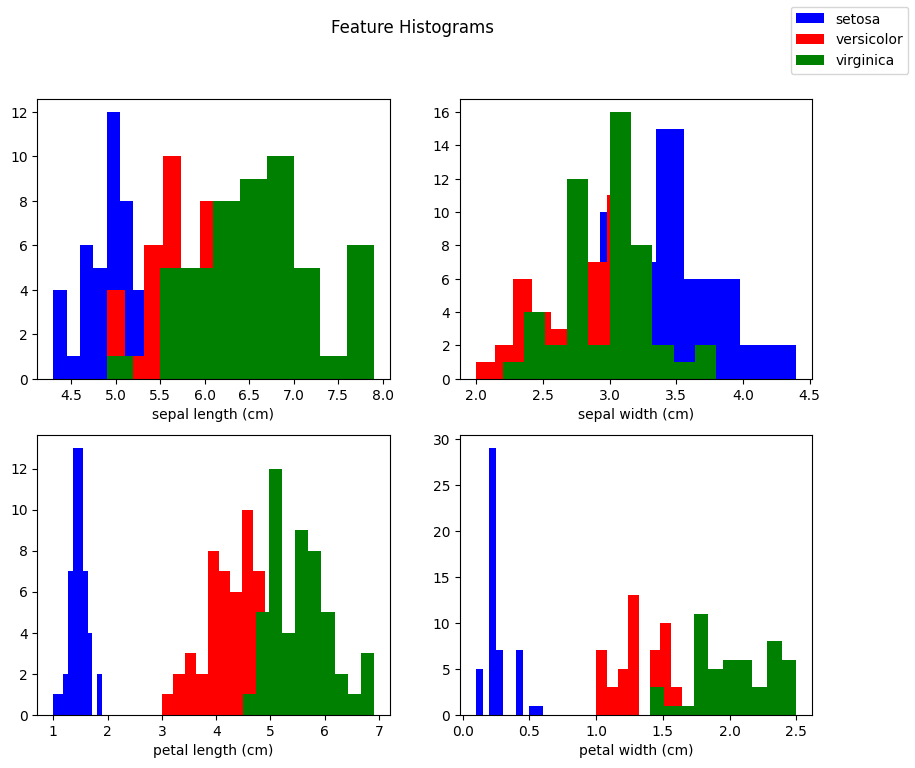

In [22]:
fig, axs = plt.subplots(2, 2, figsize=(10,8))
fig.suptitle("Feature Histograms")
for x_index in range(n_features):
    colors = ['blue', 'red', 'green']
    # Runs 3x
    for label, color in zip(range(len(iris.target_names)), colors):
        axs[x_index//2, x_index%2].hist(iris.data[iris.target==label, x_index],
                label=iris.target_names[label],
                color=color)
    axs[x_index//2, x_index%2].set_xlabel(iris.feature_names[x_index]) # X_Label
fig.legend(iris.target_names)
plt.show()

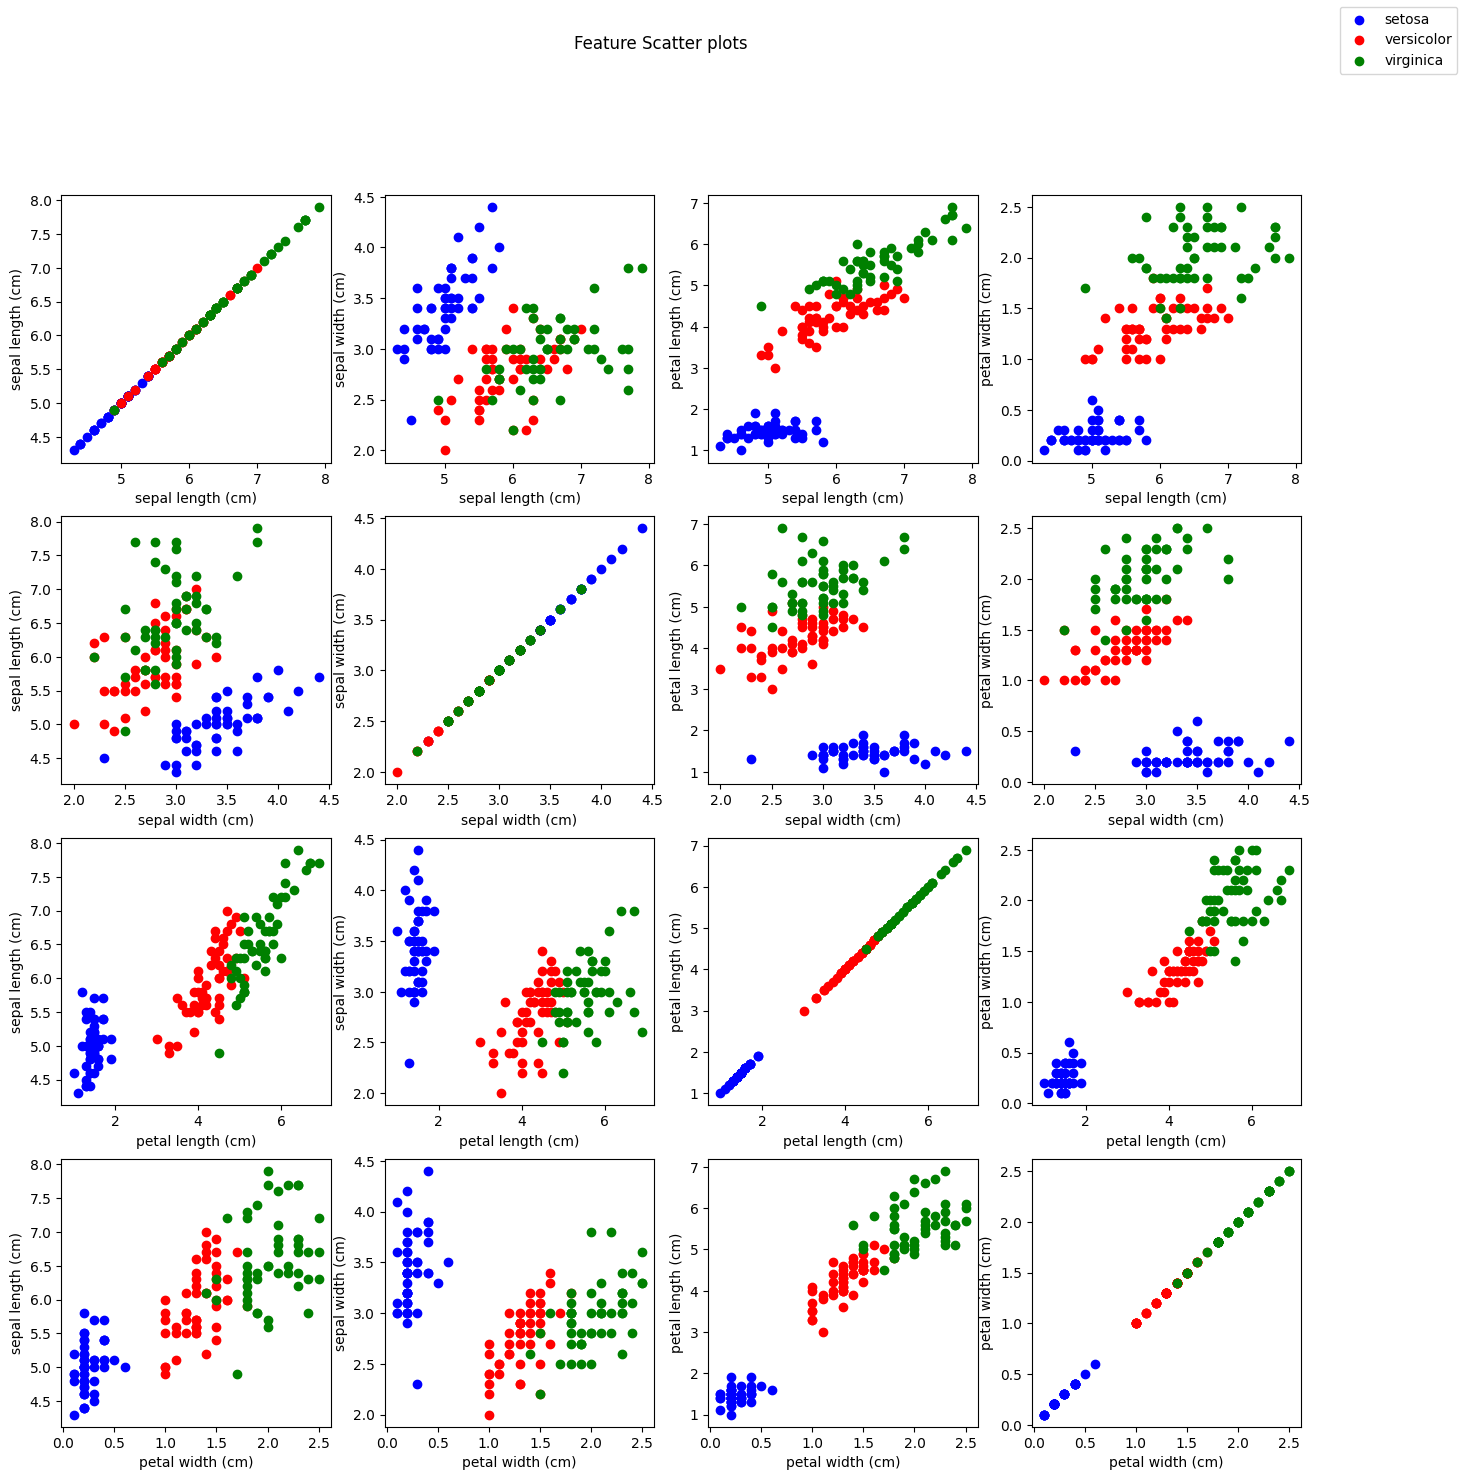

In [29]:
n = len(iris.feature_names)
fig, axs = plt.subplots(n, n, figsize=(16,16))
fig.suptitle("Feature Scatter plots")
for x in range(n):
    for y in range(n):
        for color_id in range(len(iris.target_names)):
            axs[x, y].scatter(iris.data[iris.target==color_id, x],
                        iris.data[iris.target==color_id, y],
                        label=iris.target_names[color_id],
                        c=colors[color_id])
        axs[x, y].set_xlabel(iris.feature_names[x])
        axs[x, y].set_ylabel(iris.feature_names[y])
fig.legend(iris.target_names)
plt.show()

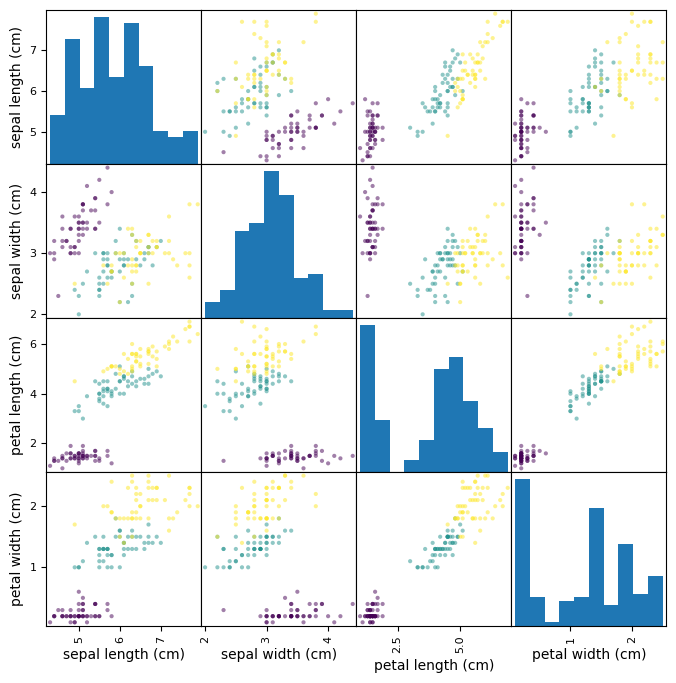

In [35]:
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
_ = pd.plotting.scatter_matrix(iris_df, c=iris.target, figsize=(8, 8))

# Digits Data
**Context**: 1797 8x8 images, 10 digits (0-9) - Target Classes <br>
**Features** - (64): pixel numbers

In [ ]:
from sklearn.datasets import load_digits

In [ ]:
digits = load_digits() # Bunch object
# Dict -> {
#           "data": List[64 floats (features)],
#           "target": int [0-9],
#           "target_names": List[0-9],
#           "feature_names": List[64 str (features)], -> string of pixel_numbers
#           "frame": None,
#           "DESCR": str(path, description),
#           "images": NDarray.shape[1797, 8, 8]
#         }
# n_samples = 1797
# n_features = 64

### Data Visualization

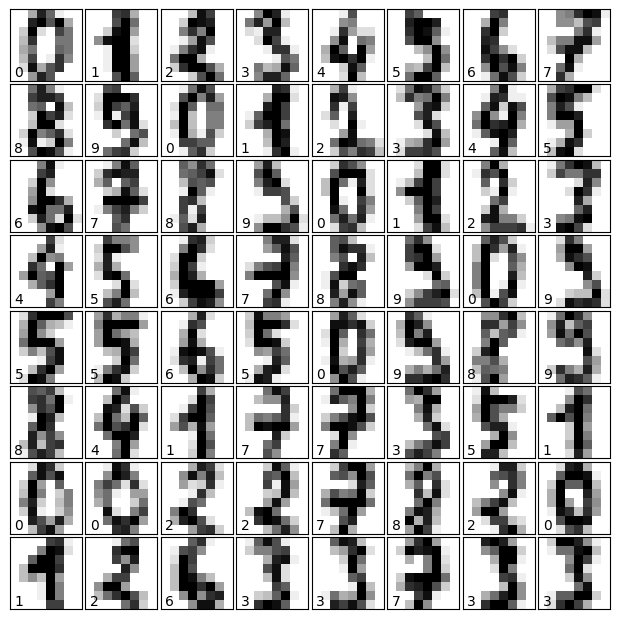

In [24]:
fig = plt.figure(figsize=(6, 6))  # figure size in inches
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)
# Plot the digits - Image [8x8 pixels]
for i in range(64):
    ax = fig.add_subplot(8, 8, i + 1, xticks=[], yticks=[]) # xticks and yticks empty for a reason
    ax.imshow(digits.images[i], cmap=plt.cm.binary, interpolation='nearest')
    # label the image with the target value
    ax.text(0, 7, str(digits.target[i]))